<a href="https://colab.research.google.com/github/Thaer-F-Ali/Logistitc_Regression_Implimitation/blob/main/logistic_regression_implimintaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification tasks. Below is a Python implementation using the scikit-learn library.

Steps to Implement Logistic Regression

1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2. Load and Prepare the Dataset

For demonstration, we'll use the diabetes dataset from sklearn.

In [ ]:
from sklearn.datasets import load_diabetes
# Load dataset
data = load_diabetes()
X, y = data.data, data.target
# Convert target to binary (1 for diabetes, 0 for no diabetes)
y_binary = (y > np.median(y)).astype(int)

3. Split the Dataset

Split the data into training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

4. Feature Scaling

Standardize features to improve model performance.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Train the Logistic Regression Model

Fit the logistic regression model on the training data.

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

6. Evaluate the Model

Evaluate the model's performance using accuracy and other metrics.

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[9], y_pred[25])
print('Raw Model Output X_test: ',
      (model.coef_@ X_test[1]+model.intercept_),
      (model.coef_@X_test[9]+model.intercept_),
      (model.coef_@X_test[25] + model.intercept_))


# 2nd Logistic Regersion

This model is from the Applied Machine Learning with Python book-page 62

In [ ]:
X = data.data
y = data.target
print(data.feature_names)
print(data.DESCR)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

### Comparing Coefficients of Scaled vs. Unscaled Models

In [ ]:
print('Prediction:', lr.predict(X_test)[1], lr.predict(X_test)[9], lr.predict(X_test)[25])
print('Raw Model Output X_test: ',
      (lr.coef_@ X_test[1] + lr.intercept_),
      (lr.coef_@ X_test[9] + lr.intercept_),
      (lr.coef_@ X_test[25]+ lr.intercept_))


In [ ]:
print("Scaled Model (model):")
print("  Coefficients:", model.coef_)
print("  Intercept:", model.intercept_)

print("\nUnscaled Model (lr):")
print("  Coefficients:", lr.coef_)
print("  Intercept:", lr.intercept_)

# 3rd Logistic Regression with data analysis in real example

*   This example is from the Kegale platform with name Diabetes Analysis
*   The dataset is a collection from  African-American patients were included


---





In [2]:
#import important libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import seaborn as sns
from scipy.stats import norm
import statistics
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [3]:
# 1. Importing dataset
# Please upload 'diabetes.csv' to your Colab session, or provide the correct path.
diab_data= pd.read_csv('/content/sample_data/Db.csv')
diab_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,12.0,92.0,62.0,7.0,258.0,27.6,0.926,44.0,1.0
1,6.0,129.0,90.0,7.0,326.0,19.6,0.582,60.0,0.0
2,1.0,109.0,60.0,8.0,182.0,25.4,0.947,21.0,0.0
3,3.0,113.0,50.0,10.0,85.0,29.5,0.626,25.0,0.0
4,0.0,74.0,52.0,10.0,36.0,27.8,0.269,22.0,0.0


In [4]:
# Rename the boood_glucose_level to glyhd
diab_data = diab_data.rename(columns={'Outcome': 'glyhb'})
diab_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
0,12.0,92.0,62.0,7.0,258.0,27.6,0.926,44.0,1.0
1,6.0,129.0,90.0,7.0,326.0,19.6,0.582,60.0,0.0
2,1.0,109.0,60.0,8.0,182.0,25.4,0.947,21.0,0.0
3,3.0,113.0,50.0,10.0,85.0,29.5,0.626,25.0,0.0
4,0.0,74.0,52.0,10.0,36.0,27.8,0.269,22.0,0.0


In [ ]:
# Exploring data in the dataset
diab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85915 entries, 0 to 85914
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           85915 non-null  object 
 1   age              85914 non-null  float64
 2   hypertension     85914 non-null  float64
 3   heart_disease    85914 non-null  float64
 4   smoking_history  85914 non-null  object 
 5   bmi              85914 non-null  float64
 6   HbA1c_level      85914 non-null  float64
 7   glyhb            85914 non-null  float64
 8   diabetes         85914 non-null  float64
dtypes: float64(7), object(2)
memory usage: 5.9+ MB


### Building LR model

Descriptive statistics for 'diabetes' column:


,DiabetesPedigreeFunction
count,394.000000
mean,0.525543
std,0.350127
min,0.085000
25%,0.270250
50%,0.449500
75%,0.687000
max,2.420000


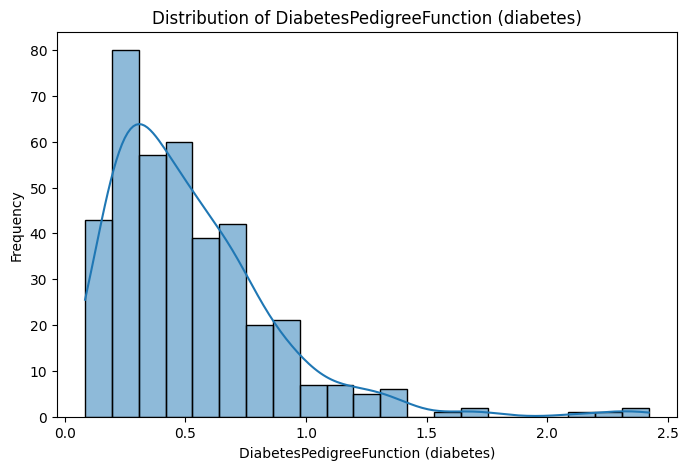

In [8]:
# 2.Understanding the 'diabetes' column
# Display descriptive statistics for 'diabetes'
print("Descriptive statistics for 'diabetes' column:")
display(diab_data['DiabetesPedigreeFunction'].describe())

# Visualize the distribution of 'glyhd'
plt.figure(figsize=(8, 5))
sns.histplot(diab_data['DiabetesPedigreeFunction'], kde=True)
plt.title('Distribution of DiabetesPedigreeFunction (diabetes)')
plt.xlabel('DiabetesPedigreeFunction (diabetes)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
diab_data

In [9]:
# 3 Exploring nan in the data
print(diab_data.info())
diab_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               394 non-null    float64
 1   Glucose                   394 non-null    float64
 2   BloodPressure             394 non-null    float64
 3   SkinThickness             394 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       394 non-null    float64
 6   DiabetesPedigreeFunction  394 non-null    float64
 7   Age                       394 non-null    float64
 8   glyhb                     394 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB
None


,0
Pregnancies,374
Glucose,374
BloodPressure,374
SkinThickness,374
Insulin,374
BMI,374
DiabetesPedigreeFunction,374
Age,374
glyhb,374


In [10]:
# 4 Cleaning data
# Droping rows where 'glyhb' has missing values
diab_data = diab_data.dropna(subset=['glyhb'], how='any')

In [11]:
# 5. Cheking nan in the data
print(diab_data.info())
diab_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 393
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               394 non-null    float64
 1   Glucose                   394 non-null    float64
 2   BloodPressure             394 non-null    float64
 3   SkinThickness             394 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       394 non-null    float64
 6   DiabetesPedigreeFunction  394 non-null    float64
 7   Age                       394 non-null    float64
 8   glyhb                     394 non-null    float64
dtypes: float64(9)
memory usage: 30.8 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


In [ ]:
# 6. Converting string data to number (Location, Gender, and Fram) for finding the correlattion between them
gender_map = {
    'Female': 0,
    'Male': 1
}
diab_data['gender'] = diab_data['gender'].map(gender_map)

'''location_map = {
    'Urban': 0,
    'Rural': 1
}
diab_data['location'] = diab_data['location'].map(location_map)

fram_map = {
    'No': 0,
    'Yes': 1
}
diab_data['frame'] = diab_data['frame'].map(fram_map)'''

KeyError: 'gender'

In [ ]:
# Deleting geneder column
diab_data = diab_data.drop('gender', axis=1)
diab_data = diab_data.drop(columns=['smoking_history'])


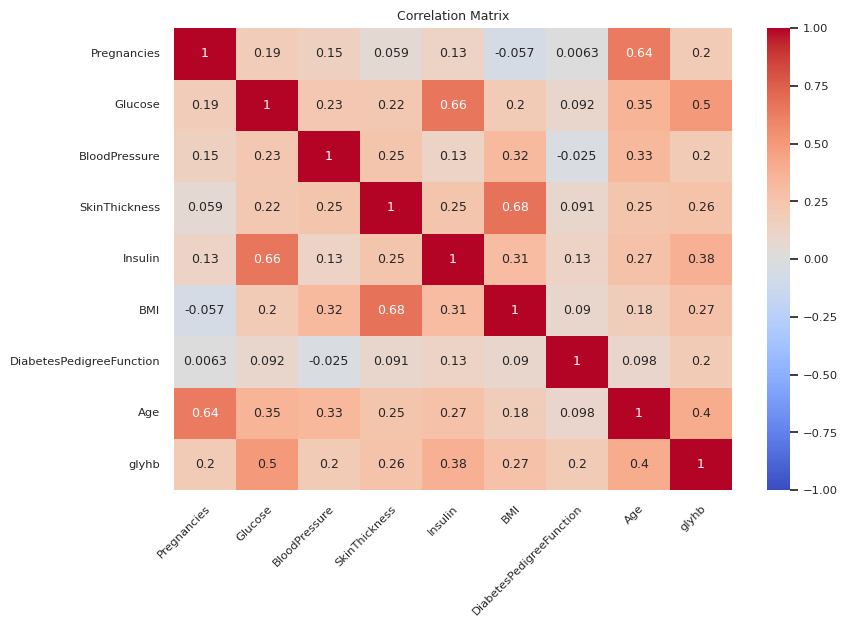

In [12]:
# 7. Cleaning dataset from the unnacessory columns ('smoking_history') to show clear corelationship

corr = diab_data.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# 8. Deleting unusfel columns that show low correlation with glyb label
diab_data_corr = diab_data.drop(['id','location', 'gender','frame'], axis =1).corr('spearman')
for col in diab_data_corr.columns:
   if (diab_data_corr['glyhb'].corr(diab_data_corr[col])<=0):
    diab_data_corr = diab_data_corr.drop(col, axis=1)

In [14]:
# 8. This step is another way to drop columns
# Dropping uncorelated columns to the glyhb column
diab_data_corr = diab_data.copy() # Make a copy to avoid modifying the original DataFrame
x = 0
for col in diab_data_corr.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue

   # Calculate correlation, handling potential NaN values if a column is all NaNs after dropna()
   if diab_data_corr[col].isnull().all(): # Check if column is entirely NaN
       correlation = 0 # Or handle as appropriate, e.g., drop it always
   else:
       correlation = diab_data_corr['glyhb'].corr(diab_data_corr[col])

   if (correlation <= 0.0):
    diab_data_corr = diab_data_corr.drop(col, axis=1)
    x = x+1
    print(f"True: Column '{col}' dropped due to correlation <= 0 (Correlation: {correlation:.2f})")
   else:
    print(f"False: Column '{col}' kept (Correlation: {correlation:.2f})")
print(f"Total columns dropped: {x}")


False: Column 'Pregnancies' kept (Correlation: 0.26)
False: Column 'Glucose' kept (Correlation: 0.51)
False: Column 'BloodPressure' kept (Correlation: 0.19)
False: Column 'SkinThickness' kept (Correlation: 0.26)
False: Column 'Insulin' kept (Correlation: 0.30)
False: Column 'BMI' kept (Correlation: 0.27)
False: Column 'DiabetesPedigreeFunction' kept (Correlation: 0.20)
False: Column 'Age' kept (Correlation: 0.35)
Skipping target column: 'glyhb'
Total columns dropped: 0


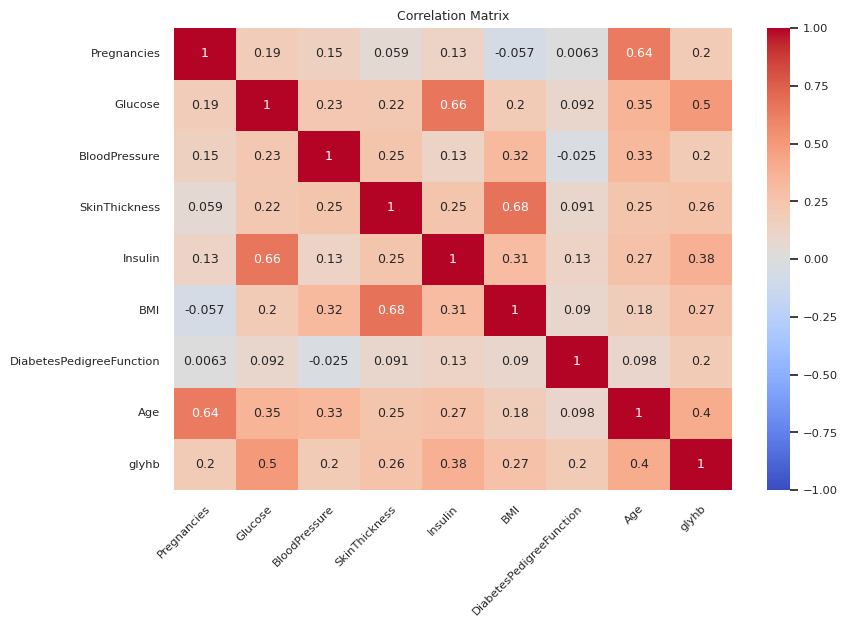

In [15]:
# 9. Exploring the correlation map with glyb for double check
corr = diab_data_corr.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [32]:
# 10. Building data for the model

# First, ensure consistency by dropping rows with any NaN values from the relevant columns
# This step ensures X and y will have the same number of samples.
diab_data_cleaned = diab_data_corr.dropna(how='any')

X = diab_data_cleaned.drop('glyhb', axis=1)
y = diab_data_cleaned['glyhb']

# Convert target to binary (1 for diabetes, 0 for no diabetes)
# Using a common clinical threshold for HbA1c: >= 6.5% for diabetes
#y_binary = (y >= 6.5).astype(int)
y_binary = (y > np.median(y)).astype(int)

# Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.2, random_state= 42)

# Normalizing data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

count    394.000000
mean       0.329949
std        0.470792
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: glyhb, dtype: float64


<Axes: xlabel='glyhb', ylabel='Count'>

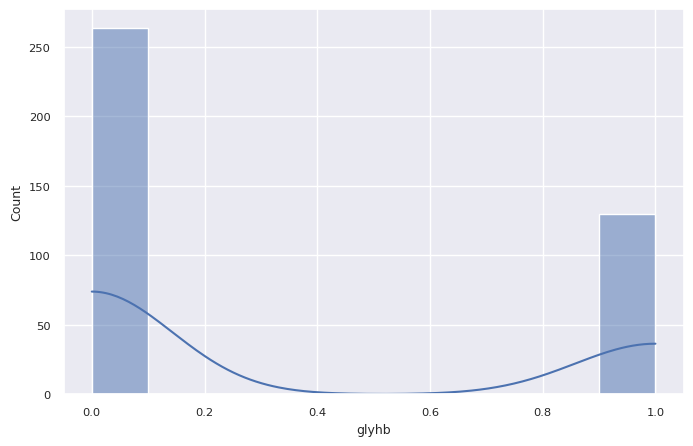

In [33]:
# 11. Exploring the glyhb column
glyb = diab_data_corr['glyhb']
print(glyb.describe())
plt.figure(figsize=(8, 5))
sns.histplot(glyb.dropna(), kde=True)

In [34]:
# 12. Building the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [35]:
# 13. Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 82.28%
Confusion Matrix:
 [[53  4]
 [10 12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88        57
           1       0.75      0.55      0.63        22

    accuracy                           0.82        79
   macro avg       0.80      0.74      0.76        79
weighted avg       0.82      0.82      0.81        79



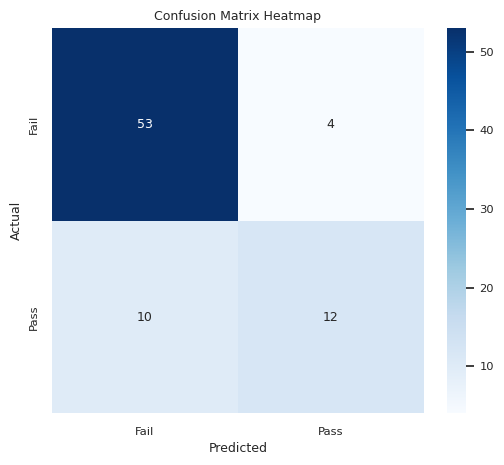

In [36]:
# 14  Plot confusion matrix as heatmap
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [38]:
# 15. Printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[30], y_pred[75])
print('Raw Model Output X_test: ',
      (model.coef_@ X_test[1]+model.intercept_),
      (model.coef_@X_test[10]+model.intercept_),
      (model.coef_@X_test[75] + model.intercept_))

Prediction: 1 0 0
Raw Model Output X_test:  [0.960675] [-3.08168174] [-3.07077033]


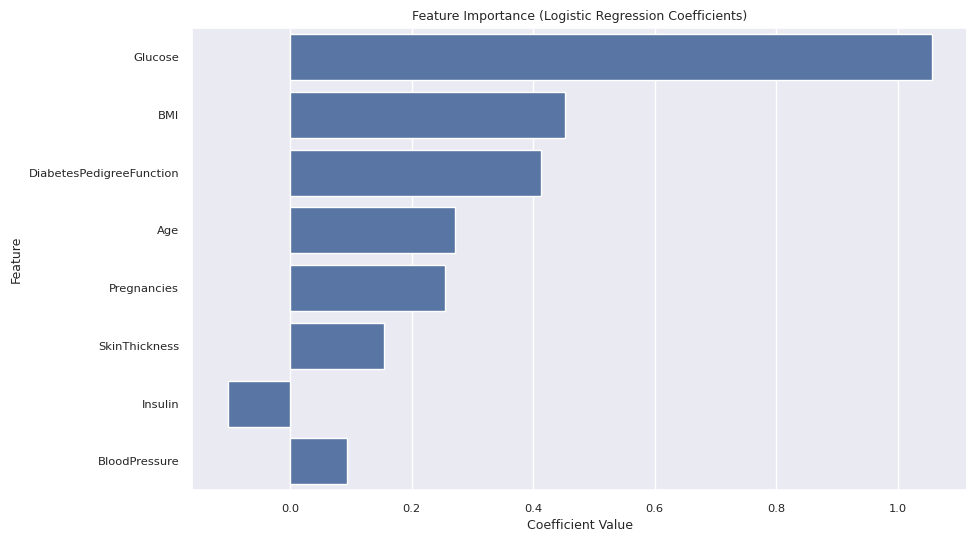

In [39]:
# 16. Coefficients for each feature
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=feature_importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

AUC Score: 0.9123


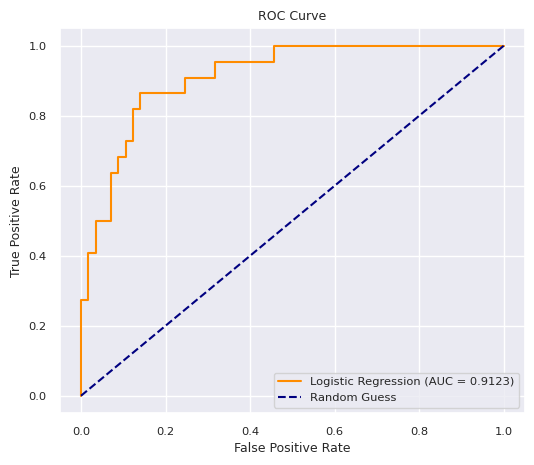

In [40]:
# 17 Plorint area under curve
#Predict probabilities for the positive class
y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate AUC
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc_score:.4f}")

# Optional: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange',  )
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
len(X_train)

315





-------------------------
# This part is for demo test

---



In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes.target[:3]
diabetes.data.shape

In [ ]:
diabetes.data[:3]

# Linear Regression

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()